Argo Float Location: Lat -61.50, Lon 178.66
Connecting to HYCOM server...
Extracting model profile (this may take a few seconds)...


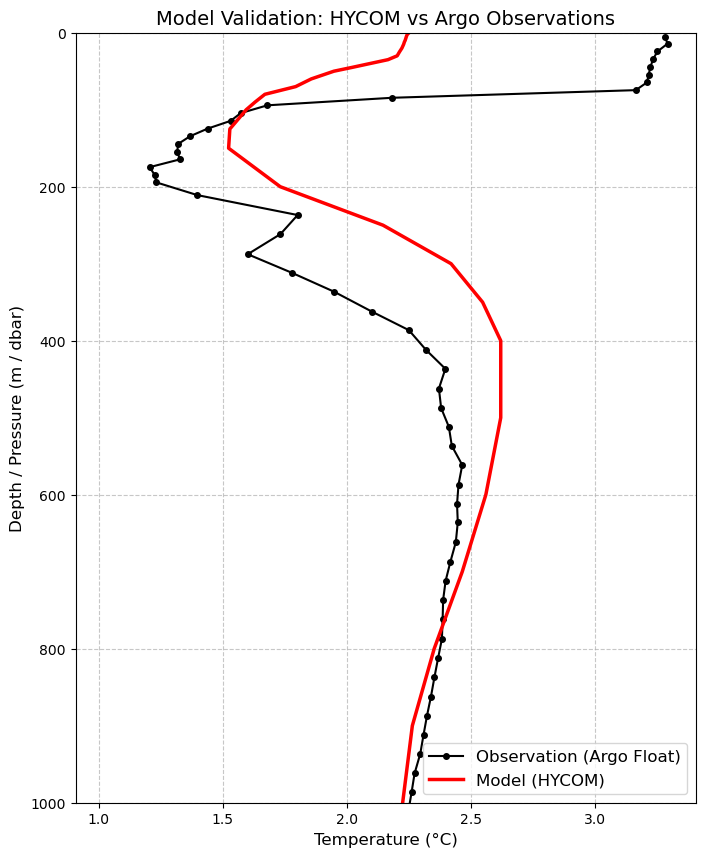

In [1]:
import os
import urllib.request
import xarray as xr
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Part 1: Load the Argo Float Observation (from Project 1)
# ---------------------------------------------------------
# We'll use the same Argo file from Project 1. If it doesn't exist here, we download it.
argo_url = "https://data-argo.ifremer.fr/dac/coriolis/6901814/6901814_prof.nc"
argo_path = "../data/6901814_prof.nc"

if not os.path.exists(argo_path):
    print("Downloading Argo data...")
    urllib.request.urlretrieve(argo_url, argo_path)

# Open Argo and select the first profile
argo_ds = xr.open_dataset(argo_path)
argo_profile = argo_ds.isel(N_PROF=0)

# Extract time, lat, and lon from the Argo profile to match the model to it
obs_time = argo_profile.JULD.values
obs_lat = argo_profile.LATITUDE.values
obs_lon = argo_profile.LONGITUDE.values

# Note: Argo longitude is often -180 to 180, while HYCOM is 0 to 360.
# We convert negative longitudes to 0-360 scale.
if obs_lon < 0:
    obs_lon_360 = obs_lon + 360
else:
    obs_lon_360 = obs_lon

print(f"Argo Float Location: Lat {obs_lat:.2f}, Lon {obs_lon_360:.2f}")

# ---------------------------------------------------------
# Part 2: Extract the HYCOM Model Data
# ---------------------------------------------------------
# Connect to HYCOM via OPeNDAP
hycom_url = "https://tds.hycom.org/thredds/dodsC/GLBy0.08/expt_93.0"
print("Connecting to HYCOM server...")
hycom_ds = xr.open_dataset(hycom_url, decode_times=False)

# Slice the model at the exact latitude and longitude of the Argo float.
# We use method='nearest' because the model grid pixels won't perfectly match the float coordinates.
print("Extracting model profile (this may take a few seconds)...")
model_profile = hycom_ds.sel(
    lat=obs_lat, 
    lon=obs_lon_360, 
    method='nearest'
).isel(time=0) # Selecting first available time for demonstration

# ---------------------------------------------------------
# Part 3: Plot the Validation
# ---------------------------------------------------------
plt.figure(figsize=(8, 10))

# Plot Argo (Observation) - Black dots
plt.plot(argo_profile.TEMP, argo_profile.PRES, 'ko-', markersize=4, label='Observation (Argo Float)')

# Plot HYCOM (Model) - Red line
plt.plot(model_profile.water_temp, model_profile.depth, 'r-', linewidth=2.5, label='Model (HYCOM)')

plt.gca().invert_yaxis() # Depth goes down
plt.ylim(1000, 0)        # Limit to upper 1000m for a clean comparison

plt.xlabel("Temperature (°C)", fontsize=12)
plt.ylabel("Depth / Pressure (m / dbar)", fontsize=12)
plt.title("Model Validation: HYCOM vs Argo Observations", fontsize=14)

plt.legend(loc='lower right', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# Save output figure
plt.savefig("../figures/model_validation.png", dpi=300, bbox_inches='tight')
plt.show()